# Faktafrågor

## 1. ***Vad kännetecknar regressionsproblem? Ge några exempel på tillämpningsområden.***

> Regressionsproblem är problem där man vill förutsäga en kontinuerlig beroende variabel utifrån en eller flera oberoende variabler. Ett exempel är att förutsäga priset på ett hus: genom att analysera egenskaper (som yta, läge och antal rum) hos liknande hus och deras faktiska försäljningspriser, kan man skapa en modell som förutsäger värdet på ett nytt hus baserat på dess egenskaper. 

## 2. ***Förklara utvärderingsmåtten RMSE, MSE och MAE.***

> Alla måtten utvärderar felmarginalen i en AI-modell, och låga värden är bättre för det är en mindre felmarginal. 
> - `RMSE` eller `Root Mean Squared Error` är ett mått som tar skillnaden mellan prediktioner och de sanna värderna, kvadrerar dessa för att få bort negativa värden (som kan slå ut positiva). Sen tar den genomsnittet av detta för att få ett värde som kan jämföras med andra och sen tar man roten ur för att motverka kvadreringen så att man får ett värde som mer liknar målvariabeln.
> - `MSE` eller `Mean Squared Error` är likadan som `RMSE` men utan att ta roten ur genomsnittet. Detta används för att när man rangordnar modeller är operationen roten ur en extra operation som tar extra resurser, detta kan bli exponentiellt när man utför utvärderingar många gånger.
> - `MAE` eller `Mean Absolute Error` tar det absoluta värdet från skillnaden av det predikterade värdet och det sanna värdet. Ett absolutbelopp ger bara positiva tal. 

## 3. ***Om vi ska rangordna olika modeller, spelar det någon roll om RMSE eller MSE används? Varför?***

> `RMSE` är oftast det värde man använder för att jämföra utvärderingar då värdet blir mer likt målvärdet jämfört med `MSE` men det är också en till operation som blir kostsam i många utvärderingar. Här är `MSE` bra då en person inte behöver tolka värdet om man ska rangordna modellers felmarginal, detta kan datorn göra själv.

## 4. ***Förklara mycket översiktligt vad gradient descent är.***

> Det är en optimeringsalgoritm som används för att hitta förlustfunktionens minimum värde, alltså det värde som indikerar minst felmarginal på en modell. 

## 5. ***Vad är the bias variance trade-off ? Varför är mer komplexa modeller inte alltid bättre?***

> Bias variance trade-off är avvägningen

## 6. ***Några vanligt förekommande modeller för regressionsproblem är enligt nedan.***
Förklara översiktligt hur respektive modell fungerar. Läs även igenom
respektive modells dokumentation, notera att du inte behöver förstå alla
detaljer från dokumentationen men det är bra att ha läst igenom den.
<br/>
    *a) Linjär regression* - https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html
<br/>
    *b) Ridge regression* - https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ridge_regression.html
<br/>
    *c) Lasso regression* - https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html
<br/>
    *d) Elastic net* - https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html
<br/>
    *e) Support vector machines* - https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html
<br/>
    *f) Beslutsträd* - https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html

## 7. ***Vad menas med white box modeller och black box modeller?***

## 8. ***Vad är skillnaden mellan bagging och pasting?***

# Resonemangsfrågor

## 9. ***Förklara hur man kan tolka figur 3.1 på sidan 113.***

## 10. ***Förklara hur man kan tolka figur 3.13 på sidan 140. Hur hänger den ihop med figur 3.14 på sidan 141?***

## 11. ***Vi har lärt oss utvärderingsmåtten RMSE, MSE och MAE. Ett annat utvärderingsmått är det som benämns för determinationskoefficienten eller 𝑅2.*** 
Förklara vad det är för mått. Du kan läsa dokumentationen om det på nedanstående två länkar.
- (https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html)
- (https://scikit-learn.org/stable/modules/model_evaluation.html#r2-score)

# Kodfrågor

## 12. ***Gå igenom samtliga kodexempel i kapitlet och skriv gärna av koden manuellt.*** 
Det är även bra att experimentera genom att ändra vissa delar av koden och läsa dokumentationen.

## 13. ***Datasetet “hr_employee_data.xlsx” innehåller data kopplat till ett företags anställda. Gör en EDA och tillhörande analys, föreställ dig att ledningsgruppen på ett företag ska ta del av analysen.***
I denna uppgift ska ingen ML-modellering göras (det kommer göras i nästa kapitel). Syftet är
dels att träna på att genomföra analyser dels att demonstrera hur mycket
man kan göra även utan ML-modellering.

## 14. ***Nedan ser vi en början till modellering av ett dataset kopplat till diabetes. Läs på vad datasetet innebär och genomför ett komplett ML-flöde.*** 
Börja med att göra ett grundläggande flöde som fungerar, därefter kan du om
du önskar försöka förbättra resultatet.
>
>```python
>    from sklearn.datasets import load_diabetes
>    from sklearn.model_selection import train_test_split
>    # This code is merely executed to see the description of
>    the data in a smooth way↪
>    data = load_diabetes()
>    print(data.DESCR)
>    # Storing/loading the data the way it will be used
>    X, y = load_diabetes(return_X_y=True, as_frame=True)
>    print(X.info())
>    print(y.info())
>    X_train, X_test, y_train, y_test = train_test_split(X, y,
>    test_size=0.2, random_state=42)
>```

## 15. ***I denna uppgift ska vi arbeta med datasetet “car_price_dataset.csv”.***

### a) Gör ett komplett ML flöde där den beroende variabeln, 𝑦, är `price`. Vi vill alltså skapa en modell som kan prediktera en bils pris. Ett tips är att först göra ett enkelt flöde som fungerar, har du därefter tid kan du försöka förbättra resultaten.

In [48]:
%reset -f

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.linear_model import LassoLars, LinearRegression, ElasticNet
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score

import joblib

In [50]:
df = pd.read_csv("../data/car_price_dataset.csv", sep=";")
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         10000 non-null  str    
 1   Model         10000 non-null  str    
 2   Year          10000 non-null  int64  
 3   Engine_Size   10000 non-null  float64
 4   Fuel_Type     10000 non-null  str    
 5   Transmission  10000 non-null  str    
 6   Mileage       10000 non-null  int64  
 7   Doors         10000 non-null  int64  
 8   Owner_Count   10000 non-null  int64  
 9   Price         10000 non-null  int64  
dtypes: float64(1), int64(5), str(4)
memory usage: 1.0 MB
None


In [51]:
df.head()

,Brand,Model,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Price
0,Kia,Rio,2020,4.2,Diesel,Manual,289944,3,5,8501
1,Chevrolet,Malibu,2012,2.0,Hybrid,Automatic,5356,2,3,12092
2,Mercedes,GLA,2020,4.2,Diesel,Automatic,231440,4,2,11171
3,Audi,Q5,2023,2.0,Electric,Manual,160971,2,1,11780
4,Volkswagen,Golf,2003,2.6,Hybrid,Semi-Automatic,286618,3,3,2867


In [52]:
df = df.dropna()

df.isna().sum().count()

np.int64(10)

In [53]:
# Extracting X and y, without str values
X = df.drop(columns=["Price","Engine_Size", "Doors", "Owner_Count"])
y = df["Price"]

Removing Engine size, doors and owner count, I theorize they aren't as necessary for calculating value of car as the others

In [54]:
X = pd.get_dummies(X, columns=["Brand", "Model", "Fuel_Type", "Transmission"])

X.head()

,Year,Mileage,Brand_Audi,Brand_BMW,Brand_Chevrolet,Brand_Ford,Brand_Honda,Brand_Hyundai,Brand_Kia,Brand_Mercedes,...,Model_Tiguan,Model_Tucson,Model_X5,Fuel_Type_Diesel,Fuel_Type_Electric,Fuel_Type_Hybrid,Fuel_Type_Petrol,Transmission_Automatic,Transmission_Manual,Transmission_Semi-Automatic
0,2020,289944,False,False,False,False,False,False,True,False,...,False,False,False,True,False,False,False,False,True,False
1,2012,5356,False,False,True,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False
2,2020,231440,False,False,False,False,False,False,False,True,...,False,False,False,True,False,False,False,True,False,False
3,2023,160971,True,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
4,2003,286618,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True


(array([ 490.,  873., 1396., 1821., 1939., 1637., 1102.,  536.,  174.,
          32.]),
 array([ 2000. ,  3630.1,  5260.2,  6890.3,  8520.4, 10150.5, 11780.6,
        13410.7, 15040.8, 16670.9, 18301. ]),
 <BarContainer object of 10 artists>)

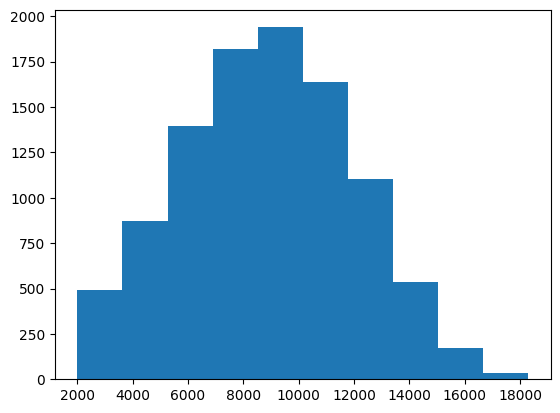

In [55]:
plt.hist(y)

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1337)

print("train size:", X_train.shape)
print("test size:", X_test.shape)

train size: (8000, 49)
test size: (2000, 49)


In [57]:
pipeline = make_pipeline(StandardScaler(), LassoLars(random_state=1337))

param_grid = {
    "lassolars__alpha":[0.1, 0.3, 0.5, 1, 10]
}
lars_gs = GridSearchCV(pipeline, param_grid,scoring="neg_mean_squared_error",n_jobs=-1)
lars_gs.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...state=1337))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'lassolars__alpha': [0.1, 0.3, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: int, default=0Controls the verbosity of information 

In [58]:
print(lars_gs.best_params_)
pd.DataFrame(lars_gs.cv_results_)

{'lassolars__alpha': 10}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_lassolars__alpha,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.084247,0.005086,0.010466,0.002109,0.1,{'lassolars__alpha': 0.1},-1.349448e+06,-1.346997e+06,-1.329491e+06,-1.262936e+06,-1.318886e+06,-1.321552e+06,31405.968758,5
1,0.076825,0.013376,0.015973,0.009377,0.3,{'lassolars__alpha': 0.3},-1.349318e+06,-1.346826e+06,-1.329375e+06,-1.262707e+06,-1.318785e+06,-1.321402e+06,31436.027956,4
2,0.061703,0.005947,0.009116,0.001682,0.5,{'lassolars__alpha': 0.5},-1.349199e+06,-1.346657e+06,-1.329262e+06,-1.262481e+06,-1.318686e+06,-1.321257e+06,31467.833905,3
3,0.063699,0.004645,0.007601,0.001824,1.0,{'lassolars__alpha': 1},-1.348920e+06,-1.346273e+06,-1.329009e+06,-1.261926e+06,-1.318416e+06,-1.320909e+06,31555.593287,2
4,0.056327,0.003445,0.003665,0.000117,10.0,{'lassolars__alpha': 10},-1.347250e+06,-1.343993e+06,-1.326497e+06,-1.252798e+06,-1.315123e+06,-1.317132e+06,34232.089523,1


In [59]:
final_lars = lars_gs.best_estimator_

final_lars.fit(X, y)

final_lars_pred = final_lars.predict(X_test)

print(r2_score(y_test, final_lars_pred))
print(root_mean_squared_error(y_test, final_lars_pred))

0.8701447410265917
1137.5553336532319


In [60]:
joblib.dump(
    filename="../models/kap_3_15_model.joblib", 
    value=final_lars)

X.to_csv("../data/pruned_car_price_dataset.csv")

In [61]:
model = joblib.load("../models/kap_3_15_model.joblib")

model.predict(X_test)

array([ 8510.13137016,  8812.57649376, 14560.85005522, ...,
        7510.10940093, 10925.09287807,  7899.55796174], shape=(2000,))

### b) Gör en applikation med hjälp av Streamlit där användaren kan mata in olika uppgifter om en bil och därefter få ett predikterat pris. <br/> Du kan se följande video för att lära dig mer om hur Streamlit fungerar:
https://www.youtube.com/watch?v=ggDa-RzPP7A&list=PLgzaMbMPEHEx9Als3F3sKKXexWnyEKH45&index=11&t=158s

[Kod för Streamlit app här](kapitel_3_15_app.py)

c) Det du gjort i denna uppgift, hade det kunnat användas i verkligheten?
Till vad i sådana fall?

## 16. I denna uppgift ska du göra ett komplett ML-flöde där du modellerar diamantpriser som finns tillgängliga i datasetet “diamonds.csv”. 
<br/>Du kan läsa mer om datasetet här: https://www.kaggle.com/datasets/shivam2503/diamonds